# 03 - Kernel Methods: SVM, Kernel Ridge and Kernel PCA

**Advanced Machine Learning** | Haydar Kilic

A kernel is an inner product taken in a feature space we never build:
$k(x, x') = \langle \phi(x), \phi(x')\rangle_{\mathcal{H}}$. Whenever an
algorithm can be written purely in terms of inner products, replacing them with
$k$ makes it non-linear at no extra representational cost. The representer
theorem justifies this: the minimiser of a regularised risk over an RKHS lies
in the span of the training points,

$$f^\star(\cdot) = \sum_{i=1}^n \alpha_i\, k(x_i, \cdot).$$

So the $n$ dual coefficients $\alpha$ replace an (often infinite-dimensional)
primal weight vector.

In [1]:
# =========================================================================
# Toolkit for this lecture: the implementations used below, inlined so the
# notebook runs on its own (NumPy / SciPy / Matplotlib only).
# Read them alongside the derivations -- each block mirrors one formula.
# =========================================================================
from __future__ import annotations

import numpy as np

# --- datasets ------------------------------------------------------

def _rng(random_state: int | np.random.Generator | None) -> np.random.Generator:
    if isinstance(random_state, np.random.Generator):
        return random_state
    return np.random.default_rng(random_state)

def make_sine(n_samples=100, noise=0.2, x_range=(-3.0, 3.0), random_state=None):
    r"""1-D regression problem :math:`y = \sin(x) + \varepsilon`."""
    rng = _rng(random_state)
    X = rng.uniform(x_range[0], x_range[1], size=(n_samples, 1))
    y = np.sin(X[:, 0]) + noise * rng.standard_normal(n_samples)
    return X, y

def make_two_moons(n_samples=200, noise=0.2, random_state=None):
    """Two interleaving half circles -- the canonical non-linear 2-class toy."""
    rng = _rng(random_state)
    n_out = n_samples // 2
    n_in = n_samples - n_out
    t_out = np.linspace(0, np.pi, n_out)
    t_in = np.linspace(0, np.pi, n_in)
    outer = np.stack([np.cos(t_out), np.sin(t_out)], axis=1)
    inner = np.stack([1 - np.cos(t_in), 0.5 - np.sin(t_in)], axis=1)
    X = np.vstack([outer, inner]) + noise * rng.standard_normal((n_samples, 2))
    y = np.hstack([np.zeros(n_out, dtype=int), np.ones(n_in, dtype=int)])
    perm = rng.permutation(n_samples)
    return X[perm], y[perm]

def train_test_split(*arrays, test_size=0.25, random_state=None, stratify=None):
    """Shuffle-split arrays, optionally stratified by ``stratify`` labels."""
    if not arrays:
        raise ValueError("At least one array is required.")
    n = len(arrays[0])
    for arr in arrays:
        if len(arr) != n:
            raise ValueError("All arrays must share the same first dimension.")
    rng = _rng(random_state)

    if stratify is None:
        idx = rng.permutation(n)
        n_test = int(round(test_size * n))
        test_idx, train_idx = idx[:n_test], idx[n_test:]
    else:
        stratify = np.asarray(stratify)
        train_parts, test_parts = [], []
        for value in np.unique(stratify):
            group = np.flatnonzero(stratify == value)
            group = group[rng.permutation(len(group))]
            n_test = int(round(test_size * len(group)))
            test_parts.append(group[:n_test])
            train_parts.append(group[n_test:])
        train_idx = np.concatenate(train_parts)
        test_idx = np.concatenate(test_parts)
        train_idx = train_idx[rng.permutation(len(train_idx))]
        test_idx = test_idx[rng.permutation(len(test_idx))]

    out = []
    for arr in arrays:
        arr = np.asarray(arr)
        out.extend([arr[train_idx], arr[test_idx]])
    return tuple(out)

# --- metrics -------------------------------------------------------

def mse(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true, float), np.asarray(y_pred, float)
    return float(np.mean((y_true - y_pred) ** 2))

def accuracy(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    return float(np.mean(y_true == y_pred))

# --- kernels -------------------------------------------------------

def squared_distances(X, Y=None):
    """Pairwise squared Euclidean distances, clipped at zero for stability."""
    X = np.asarray(X, float)
    Y = X if Y is None else np.asarray(Y, float)
    d2 = (X**2).sum(1)[:, None] + (Y**2).sum(1)[None, :] - 2.0 * X @ Y.T
    return np.maximum(d2, 0.0)

def linear_kernel(X, Y=None, c=0.0):
    Y = X if Y is None else Y
    return np.asarray(X, float) @ np.asarray(Y, float).T + c

def polynomial_kernel(X, Y=None, degree=3, gamma=None, coef0=1.0):
    r""":math:`(\gamma\,x^\top y + c_0)^d`."""
    X = np.asarray(X, float)
    Y = X if Y is None else np.asarray(Y, float)
    gamma = 1.0 / X.shape[1] if gamma is None else gamma
    return (gamma * (X @ Y.T) + coef0) ** degree

def rbf_kernel(X, Y=None, gamma=None, length_scale=None):
    r""":math:`\exp(-\gamma\|x-y\|^2)`; ``length_scale`` sets :math:`\gamma = 1/(2\ell^2)`."""
    X = np.asarray(X, float)
    if length_scale is not None:
        gamma = 1.0 / (2.0 * length_scale**2)
    if gamma is None:
        gamma = 1.0 / X.shape[1]
    return np.exp(-gamma * squared_distances(X, Y))

def laplacian_kernel(X, Y=None, gamma=1.0):
    r""":math:`\exp(-\gamma\|x-y\|_1)` -- less smooth than the RBF."""
    X = np.asarray(X, float)
    Y = X if Y is None else np.asarray(Y, float)
    dist = np.abs(X[:, None, :] - Y[None, :, :]).sum(-1)
    return np.exp(-gamma * dist)

def matern_kernel(X, Y=None, length_scale=1.0, nu=1.5):
    r"""Matérn kernel for :math:`\nu \in \{1/2, 3/2, 5/2\}`.

    Sample paths are :math:`\lceil \nu \rceil - 1` times differentiable, so the
    kernel interpolates between the Laplacian (:math:`\nu=1/2`) and the RBF
    (:math:`\nu \to \infty`).
    """
    d = np.sqrt(squared_distances(X, Y))
    if nu == 0.5:
        return np.exp(-d / length_scale)
    if nu == 1.5:
        a = np.sqrt(3.0) * d / length_scale
        return (1.0 + a) * np.exp(-a)
    if nu == 2.5:
        a = np.sqrt(5.0) * d / length_scale
        return (1.0 + a + a**2 / 3.0) * np.exp(-a)
    raise ValueError("nu must be 0.5, 1.5 or 2.5.")

def sigmoid_kernel(X, Y=None, gamma=0.01, coef0=0.0):
    r""":math:`\tanh(\gamma x^\top y + c_0)` -- not PSD in general, kept for teaching."""
    X = np.asarray(X, float)
    Y = X if Y is None else np.asarray(Y, float)
    return np.tanh(gamma * (X @ Y.T) + coef0)

_KERNELS = {
    "linear": linear_kernel,
    "poly": polynomial_kernel,
    "polynomial": polynomial_kernel,
    "rbf": rbf_kernel,
    "laplacian": laplacian_kernel,
    "matern": matern_kernel,
    "sigmoid": sigmoid_kernel,
}

def get_kernel(name, **params):
    """Return ``k(X, Y)`` for a kernel name with the given hyper-parameters."""
    if callable(name):
        return name
    try:
        base = _KERNELS[name]
    except KeyError as exc:
        raise ValueError(f"Unknown kernel {name!r}. Options: {sorted(_KERNELS)}") from exc
    return lambda X, Y=None: base(X, Y, **params)

def center_gram(K, K_fit=None):
    r"""Centre a Gram matrix in feature space.

    For training, :math:`\tilde K = (I - \frac{1}{n}\mathbf{1}\mathbf{1}^\top) K
    (I - \frac{1}{n}\mathbf{1}\mathbf{1}^\top)`; pass ``K_fit`` (the training
    Gram) to centre a test Gram consistently.
    """
    K = np.asarray(K, float)
    if K_fit is None:
        n = K.shape[0]
        one = np.full((n, n), 1.0 / n)
        return K - one @ K - K @ one + one @ K @ one
    row_mean_fit = K_fit.mean(axis=0)
    total_mean = K_fit.mean()
    return K - K.mean(axis=1, keepdims=True) - row_mean_fit[None, :] + total_mean

def is_psd(K, tol=1e-8):
    """Numerical PSD check on a symmetrised Gram matrix."""
    K = np.asarray(K, float)
    return bool(np.all(np.linalg.eigvalsh(0.5 * (K + K.T)) > -tol))

# --- svm -----------------------------------------------------------

class SVC:
    """Binary kernel SVM trained with SMO.

    Labels may be given as ``{0, 1}`` or ``{-1, +1}``; they are mapped to
    :math:`\\pm 1` internally and restored on ``predict``.
    """

    def __init__(self, C=1.0, kernel="rbf", tol=1e-3, max_passes=20, max_iter=20000,
                 random_state=None, **kernel_params):
        self.C = float(C)
        self.kernel = kernel
        self.kernel_params = kernel_params
        self.tol = float(tol)
        self.max_passes = int(max_passes)
        self.max_iter = int(max_iter)
        self.random_state = random_state

    # ------------------------------------------------------------------ fit
    def fit(self, X, y):
        """Platt's SMO: alternate full sweeps and sweeps over non-bound alphas."""
        X = np.asarray(X, float)
        y = np.asarray(y)
        self.classes_ = np.unique(y)
        if len(self.classes_) != 2:
            raise ValueError("SVC handles binary problems only.")
        y_pm = np.where(y == self.classes_[1], 1.0, -1.0)

        self._kernel_fn = get_kernel(self.kernel, **self.kernel_params)
        K = self._kernel_fn(X, X)
        n = len(X)

        state = {
            "alpha": np.zeros(n),
            "b": 0.0,
            "f": np.zeros(n),  # f_i = sum_j alpha_j y_j K(i, j)
            "iters": 0,
        }
        rng = np.random.default_rng(self.random_state)

        examine_all = True
        n_changed = 0
        sweeps = 0
        while (n_changed > 0 or examine_all) and state["iters"] < self.max_iter:
            n_changed = 0
            if examine_all:
                indices = range(n)
            else:
                alpha = state["alpha"]
                indices = np.flatnonzero((alpha > 1e-8) & (alpha < self.C - 1e-8))
            for i in indices:
                n_changed += self._examine(int(i), K, y_pm, state, rng)
            sweeps += 1
            if sweeps > self.max_passes * 10:
                break
            if examine_all:
                examine_all = False
            elif n_changed == 0:
                examine_all = True

        alpha, b = state["alpha"], state["b"]
        sv = alpha > 1e-8
        self.alpha_ = alpha
        self.dual_coef_ = alpha[sv] * y_pm[sv]
        self.support_vectors_ = X[sv]
        self.support_ = np.flatnonzero(sv)
        self.intercept_ = float(b)
        self.n_iter_ = state["iters"]
        self.dual_objective_ = float(
            alpha.sum() - 0.5 * np.sum(np.outer(alpha * y_pm, alpha * y_pm) * K)
        )
        return self

    # ------------------------------------------------------------------- SMO
    def _error(self, i, y_pm, state):
        return state["f"][i] + state["b"] - y_pm[i]

    def _examine(self, i, K, y_pm, state, rng):
        """Try to make progress on multiplier ``i``; return 1 if a pair moved."""
        alpha, C = state["alpha"], self.C
        E_i = self._error(i, y_pm, state)
        r_i = y_pm[i] * E_i
        if not ((r_i < -self.tol and alpha[i] < C) or (r_i > self.tol and alpha[i] > 0)):
            return 0  # KKT conditions already satisfied for i

        non_bound = np.flatnonzero((alpha > 1e-8) & (alpha < C - 1e-8))
        # heuristic 1: largest |E_i - E_j| among non-bound multipliers
        if len(non_bound) > 1:
            errors = state["f"][non_bound] + state["b"] - y_pm[non_bound]
            j = int(non_bound[int(np.argmax(np.abs(errors - E_i)))])
            if j != i and self._take_step(i, j, K, y_pm, state):
                return 1
        # heuristic 2: all non-bound multipliers, starting at a random offset
        for j in _rotated(non_bound, rng):
            if j != i and self._take_step(i, int(j), K, y_pm, state):
                return 1
        # heuristic 3: everything else
        for j in _rotated(np.arange(len(alpha)), rng):
            if j != i and self._take_step(i, int(j), K, y_pm, state):
                return 1
        return 0

    def _take_step(self, i, j, K, y_pm, state):
        """Analytic optimisation of the pair (i, j); returns True if it moved."""
        alpha, C = state["alpha"], self.C
        state["iters"] += 1
        a_i_old, a_j_old = alpha[i], alpha[j]
        E_i, E_j = self._error(i, y_pm, state), self._error(j, y_pm, state)

        if y_pm[i] != y_pm[j]:
            L = max(0.0, a_j_old - a_i_old)
            H = min(C, C + a_j_old - a_i_old)
        else:
            L = max(0.0, a_i_old + a_j_old - C)
            H = min(C, a_i_old + a_j_old)
        if H - L < 1e-12:
            return False

        eta = 2.0 * K[i, j] - K[i, i] - K[j, j]
        if eta < -1e-12:
            a_j = np.clip(a_j_old - y_pm[j] * (E_i - E_j) / eta, L, H)
        else:
            # non-positive curvature: evaluate the objective at both endpoints
            a_j = L if self._objective_at(i, j, L, K, y_pm, state) > \
                self._objective_at(i, j, H, K, y_pm, state) else H
        if abs(a_j - a_j_old) < 1e-9 * (a_j + a_j_old + 1e-9):
            return False
        a_i = a_i_old + y_pm[i] * y_pm[j] * (a_j_old - a_j)
        a_i = float(np.clip(a_i, 0.0, C))

        d_i = (a_i - a_i_old) * y_pm[i]
        d_j = (a_j - a_j_old) * y_pm[j]
        b_old = state["b"]
        b1 = b_old - E_i - d_i * K[i, i] - d_j * K[i, j]
        b2 = b_old - E_j - d_i * K[i, j] - d_j * K[j, j]
        if 0 < a_i < C:
            state["b"] = b1
        elif 0 < a_j < C:
            state["b"] = b2
        else:
            state["b"] = 0.5 * (b1 + b2)

        alpha[i], alpha[j] = a_i, a_j
        state["f"] += d_i * K[i] + d_j * K[j]
        return True

    def _objective_at(self, i, j, a_j, K, y_pm, state):
        """Dual objective when alpha_j is set to ``a_j`` (others fixed)."""
        alpha = state["alpha"].copy()
        gamma = alpha[i] * y_pm[i] + alpha[j] * y_pm[j]
        alpha[j] = a_j
        alpha[i] = (gamma - a_j * y_pm[j]) * y_pm[i]
        w = alpha * y_pm
        return float(alpha.sum() - 0.5 * w @ K @ w)

    # -------------------------------------------------------------- predict
    def decision_function(self, X):
        K = self._kernel_fn(np.asarray(X, float), self.support_vectors_)
        return K @ self.dual_coef_ + self.intercept_

    def predict(self, X):
        scores = self.decision_function(X)
        return np.where(scores > 0, self.classes_[1], self.classes_[0])

def _rotated(indices, rng):
    """Iterate over ``indices`` starting from a random offset (Platt's advice)."""
    indices = np.asarray(indices)
    if len(indices) == 0:
        return indices
    offset = int(rng.integers(0, len(indices)))
    return np.roll(indices, -offset)

class KernelRidge:
    r"""Kernel ridge regression: :math:`\alpha = (K + \lambda I)^{-1} y`."""

    def __init__(self, alpha=1.0, kernel="rbf", **kernel_params):
        self.alpha = float(alpha)
        self.kernel = kernel
        self.kernel_params = kernel_params

    def fit(self, X, y):
        X, y = np.asarray(X, float), np.asarray(y, float)
        self._kernel_fn = get_kernel(self.kernel, **self.kernel_params)
        self.X_fit_ = X
        K = self._kernel_fn(X, X)
        self.dual_coef_ = np.linalg.solve(K + self.alpha * np.eye(len(X)), y)
        return self

    def predict(self, X):
        return self._kernel_fn(np.asarray(X, float), self.X_fit_) @ self.dual_coef_

# --- decomposition -------------------------------------------------

class PCA:
    def __init__(self, n_components=2, whiten=False):
        self.n_components = int(n_components)
        self.whiten = whiten

    def fit(self, X, y=None):
        X = np.asarray(X, float)
        self.mean_ = X.mean(axis=0)
        Xc = X - self.mean_
        U, S, Vt = np.linalg.svd(Xc, full_matrices=False)
        q = self.n_components
        self.components_ = Vt[:q]
        var = S**2 / (len(X) - 1)
        self.explained_variance_ = var[:q]
        self.explained_variance_ratio_ = var[:q] / var.sum()
        self.singular_values_ = S[:q]
        return self

    def transform(self, X):
        Z = (np.asarray(X, float) - self.mean_) @ self.components_.T
        if self.whiten:
            Z = Z / np.sqrt(self.explained_variance_ + 1e-12)
        return Z

    def fit_transform(self, X, y=None):
        return self.fit(X).transform(X)

    def inverse_transform(self, Z):
        Z = np.asarray(Z, float)
        if self.whiten:
            Z = Z * np.sqrt(self.explained_variance_ + 1e-12)
        return Z @ self.components_ + self.mean_

class KernelPCA:
    """PCA in feature space via the centred Gram matrix."""

    def __init__(self, n_components=2, kernel="rbf", **kernel_params):
        self.n_components = int(n_components)
        self.kernel = kernel
        self.kernel_params = kernel_params

    def fit(self, X, y=None):
        X = np.asarray(X, float)
        self._kernel_fn = get_kernel(self.kernel, **self.kernel_params)
        self.X_fit_ = X
        K = self._kernel_fn(X, X)
        self.K_fit_ = K
        Kc = center_gram(K)
        eigvals, eigvecs = np.linalg.eigh(0.5 * (Kc + Kc.T))
        order = np.argsort(eigvals)[::-1][: self.n_components]
        eigvals, eigvecs = eigvals[order], eigvecs[:, order]
        eigvals = np.maximum(eigvals, 1e-12)
        # unit-norm principal directions in feature space
        self.alphas_ = eigvecs / np.sqrt(eigvals)
        self.lambdas_ = eigvals
        return self

    def transform(self, X):
        K = self._kernel_fn(np.asarray(X, float), self.X_fit_)
        return center_gram(K, self.K_fit_) @ self.alphas_

    def fit_transform(self, X, y=None):
        self.fit(X)
        return center_gram(self.K_fit_) @ self.alphas_

# --- viz -----------------------------------------------------------

PALETTE = ["#1f4e79", "#c0392b", "#27865f", "#8e44ad", "#d68910", "#2c3e50"]

def set_style():
    """Apply a clean, print-friendly default style."""
    import matplotlib as mpl
    import matplotlib.pyplot as plt

    mpl.rcParams.update({
        "figure.figsize": (7.0, 4.2),
        "figure.dpi": 110,
        "axes.grid": True,
        "grid.alpha": 0.25,
        "grid.linestyle": "--",
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.titlesize": 12,
        "axes.titleweight": "bold",
        "axes.labelsize": 10,
        "legend.frameon": False,
        "font.size": 10,
        "axes.prop_cycle": mpl.cycler(color=PALETTE),
    })
    return plt

def plot_decision_boundary(predict_fn, X, y, ax=None, resolution=250, margin=0.5,
                           levels=None, cmap="RdBu_r", alpha=0.35, title=None):
    """Fill the plane with ``predict_fn`` values and scatter the data on top.

    ``predict_fn`` may return labels or continuous scores (e.g. a decision
    function), in which case the zero level set is drawn as the boundary.
    """
    import matplotlib.pyplot as plt

    X = np.asarray(X, float)
    ax = ax or plt.gca()
    x_min, x_max = X[:, 0].min() - margin, X[:, 0].max() + margin
    y_min, y_max = X[:, 1].min() - margin, X[:, 1].max() + margin
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, resolution),
                         np.linspace(y_min, y_max, resolution))
    grid = np.column_stack([xx.ravel(), yy.ravel()])
    zz = np.asarray(predict_fn(grid), float).reshape(xx.shape)

    ax.contourf(xx, yy, zz, levels=20 if levels is None else levels, cmap=cmap,
                alpha=alpha)
    if levels is None and zz.min() < 0 < zz.max():
        ax.contour(xx, yy, zz, levels=[0.0], colors="k", linewidths=1.2)
    for i, label in enumerate(np.unique(y)):
        mask = np.asarray(y) == label
        ax.scatter(X[mask, 0], X[mask, 1], s=22, edgecolor="k", linewidth=0.4,
                   color=PALETTE[i % len(PALETTE)], label=f"class {label}", zorder=3)
    ax.legend(loc="best")
    if title:
        ax.set_title(title)
    return ax

In [2]:
plt = set_style()

X, y = make_two_moons(300, noise=0.22, random_state=0)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3,
                                                    random_state=0, stratify=y)
print(f"train {X_train.shape}, test {X_test.shape}")

train (210, 2), test (90, 2)


## 1. Kernels as similarity, Gram matrices as data

Everything the algorithms below see is the $n\times n$ Gram matrix
$K_{ij} = k(x_i, x_j)$, which must be symmetric positive semi-definite for the
feature-space interpretation to hold (Mercer's condition).

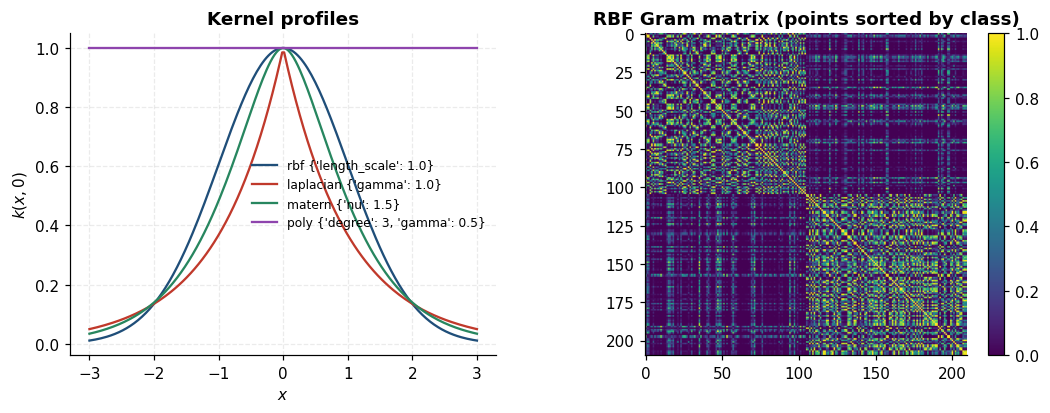

rbf      PSD: True
poly     PSD: True
sigmoid  PSD: False


In [3]:
grid = np.linspace(-3, 3, 200).reshape(-1, 1)
origin = np.zeros((1, 1))

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for name, params in [("rbf", {"length_scale": 1.0}), ("laplacian", {"gamma": 1.0}),
                     ("matern", {"nu": 1.5}), ("poly", {"degree": 3, "gamma": 0.5})]:
    axes[0].plot(grid, get_kernel(name, **params)(grid, origin).ravel(),
                 label=f"{name} {params}")
axes[0].set_xlabel("$x$")
axes[0].set_ylabel("$k(x, 0)$")
axes[0].set_title("Kernel profiles")
axes[0].legend(fontsize=8)

K = rbf_kernel(X_train[np.argsort(y_train)], length_scale=0.5)
im = axes[1].imshow(K, cmap="viridis")
axes[1].set_title("RBF Gram matrix (points sorted by class)")
axes[1].grid(False)
fig.colorbar(im, ax=axes[1], fraction=0.046)
plt.show()

for name, params in [("rbf", {}), ("poly", {"degree": 3}), ("sigmoid", {"gamma": 1.0})]:
    print(f"{name:8s} PSD: {is_psd(get_kernel(name, **params)(X_train[:60], X_train[:60]))}")

The sigmoid "kernel" fails the check -- it is only conditionally PSD, which is
why solvers can misbehave on it. This is a one-line diagnostic worth running
whenever a custom kernel is introduced.

## 2. The C-SVM dual and SMO

The soft-margin primal $\min \tfrac12\|w\|^2 + C\sum_i \xi_i$ has the dual

$$\max_\alpha \sum_i \alpha_i - \tfrac12\sum_{i,j}\alpha_i\alpha_j y_i y_j k(x_i,x_j)
\quad\text{s.t.}\quad 0\le\alpha_i\le C,\;\; \sum_i \alpha_i y_i = 0 .$$

The equality constraint means we cannot move one multiplier at a time; SMO
moves the smallest possible set -- a pair -- and solves that two-variable problem
analytically. Points with $\alpha_i > 0$ are the support vectors; only they
enter the prediction.

support vectors      : 26 / 210
dual objective       : 80.526
pair updates (SMO)   : 1440
equality constraint  : sum(alpha_i y_i) = -8.88e-16
test accuracy        : 0.967


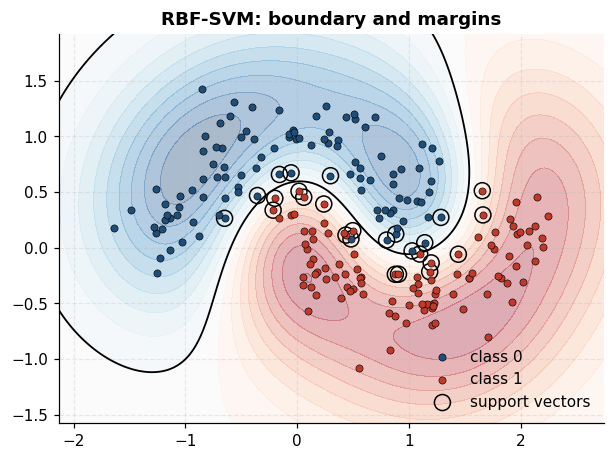

In [4]:
svm = SVC(C=5.0, kernel="rbf", gamma=1.0, random_state=0).fit(X_train, y_train)
y_pm = np.where(y_train == svm.classes_[1], 1.0, -1.0)

print(f"support vectors      : {len(svm.support_)} / {len(X_train)}")
print(f"dual objective       : {svm.dual_objective_:.3f}")
print(f"pair updates (SMO)   : {svm.n_iter_}")
print(f"equality constraint  : sum(alpha_i y_i) = {np.sum(svm.alpha_ * y_pm):.2e}")
print(f"test accuracy        : {accuracy(y_test, svm.predict(X_test)):.3f}")

fig, ax = plt.subplots(figsize=(6.4, 4.6))
plot_decision_boundary(svm.decision_function, X_train, y_train, ax=ax,
                       title="RBF-SVM: boundary and margins")
ax.scatter(svm.support_vectors_[:, 0], svm.support_vectors_[:, 1], s=110,
           facecolors="none", edgecolors="k", lw=1.0, label="support vectors")
ax.legend(loc="lower right")
plt.show()

## 3. What $C$ and $\gamma$ actually control

$C$ caps each multiplier, so a small $C$ tolerates margin violations (wide,
smooth boundary, many support vectors) while a large $C$ approaches the hard
margin. $\gamma$ sets the RBF bandwidth: large $\gamma$ makes each point
influence only its immediate neighbourhood -- memorisation.

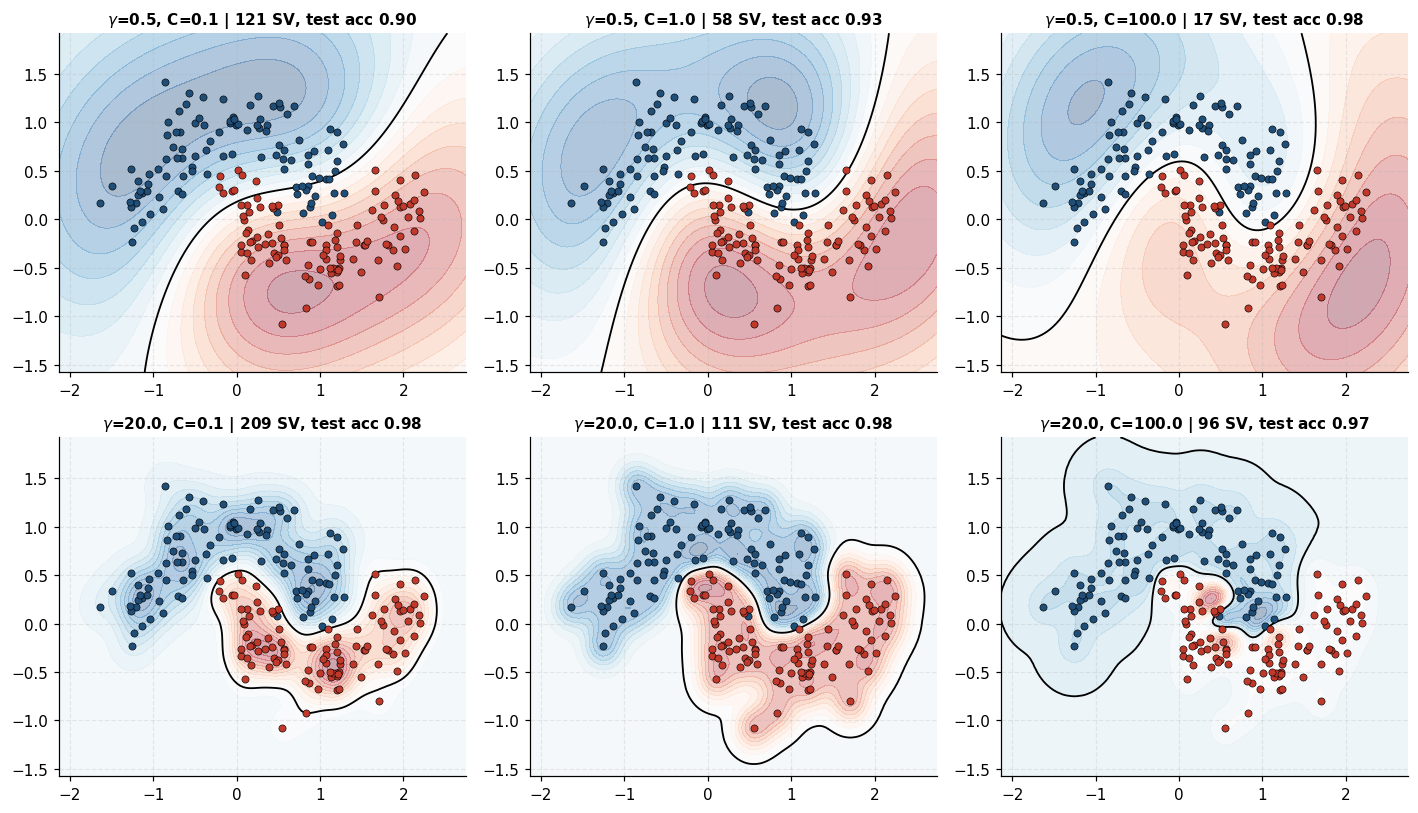

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(13, 7.5))
for row, gamma in enumerate([0.5, 20.0]):
    for col, C in enumerate([0.1, 1.0, 100.0]):
        model = SVC(C=C, kernel="rbf", gamma=gamma, random_state=0).fit(X_train, y_train)
        plot_decision_boundary(model.decision_function, X_train, y_train, ax=axes[row, col],
                               resolution=140)
        axes[row, col].set_title(
            f"$\\gamma$={gamma}, C={C} | {len(model.support_)} SV, "
            f"test acc {accuracy(y_test, model.predict(X_test)):.2f}", fontsize=10)
        axes[row, col].legend().remove()
plt.tight_layout()
plt.show()

The bottom row shows the classic failure mode: with $\gamma = 20$ the model
draws islands around individual training points, training accuracy is near
perfect and test accuracy collapses.

## 4. Kernel ridge regression: the same idea, squared loss

Replacing the hinge with squared error removes the inequality constraints and
the solution is one linear system,
$\alpha = (K + \lambda I)^{-1}y$ -- no sparsity, but no iterations either.

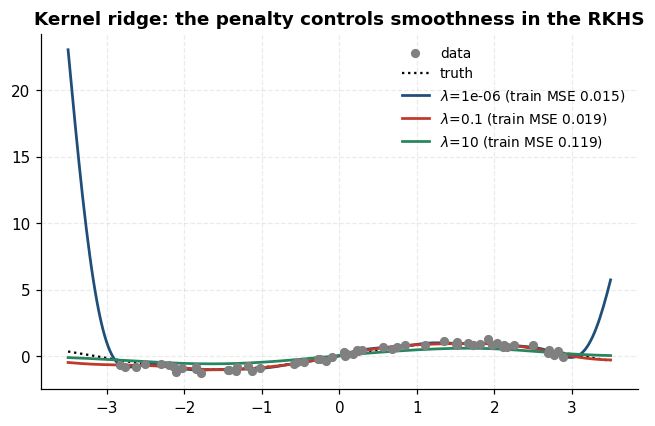

In [6]:
Xr, yr = make_sine(60, noise=0.2, random_state=1)
grid = np.linspace(-3.5, 3.5, 300).reshape(-1, 1)

fig, ax = plt.subplots()
ax.scatter(Xr, yr, s=25, color="grey", label="data", zorder=3)
ax.plot(grid, np.sin(grid), "k:", label="truth")
for lam, ls in [(1e-6, "-"), (1e-1, "-"), (10.0, "-")]:
    krr = KernelRidge(alpha=lam, kernel="rbf", length_scale=0.7).fit(Xr, yr)
    ax.plot(grid, krr.predict(grid), ls, lw=1.8,
            label=fr"$\lambda$={lam:g} (train MSE {mse(yr, krr.predict(Xr)):.3f})")
ax.set_title("Kernel ridge: the penalty controls smoothness in the RKHS")
ax.legend(fontsize=9)
plt.show()

With $\lambda \to 0$ the fit interpolates every noisy point; with $\lambda$ too
large the function is flattened toward zero. Unlike the SVM, *every* training
point has a non-zero dual coefficient -- the hinge loss is what buys sparsity.

## 5. Kernel PCA: unsupervised use of the same trick

PCA needs only inner products, so it kernelises too: diagonalise the centred
Gram matrix
$\tilde K = (I - \tfrac1n \mathbf{1}\mathbf{1}^\top)K(I - \tfrac1n \mathbf{1}\mathbf{1}^\top)$
instead of the covariance matrix. On concentric rings -- where no linear
projection can help -- the first kernel component separates the classes.

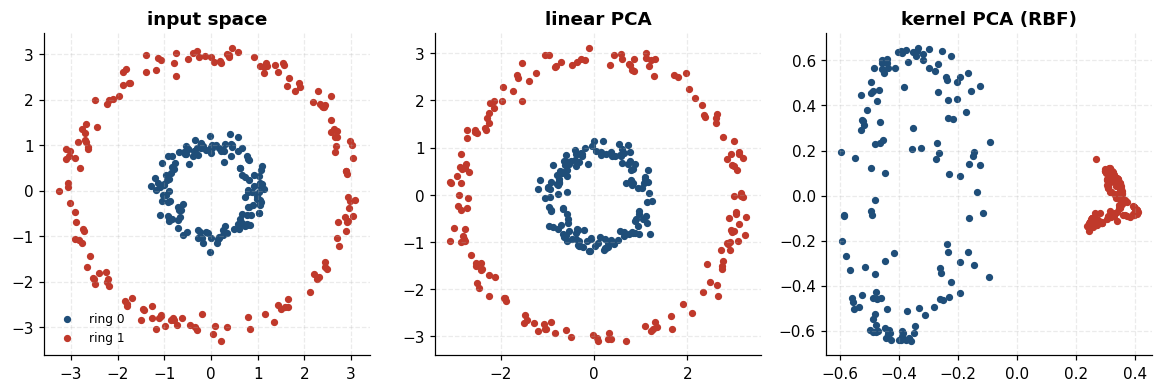

class separation on component 1 -- linear PCA: 0.01, kernel PCA: 1.93


In [7]:
rng = np.random.default_rng(2)
theta = rng.uniform(0, 2 * np.pi, 300)
radius = np.where(rng.random(300) < 0.5, 1.0, 3.0)
Xc = np.stack([radius * np.cos(theta), radius * np.sin(theta)], axis=1)
Xc += 0.12 * rng.standard_normal(Xc.shape)
labels = (radius > 2).astype(int)

Z_linear = PCA(n_components=2).fit_transform(Xc)
Z_kernel = KernelPCA(n_components=2, kernel="rbf", gamma=0.6).fit_transform(Xc)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
for ax, data, title in [(axes[0], Xc, "input space"),
                        (axes[1], Z_linear, "linear PCA"),
                        (axes[2], Z_kernel, "kernel PCA (RBF)")]:
    for k in (0, 1):
        ax.scatter(data[labels == k, 0], data[labels == k, 1], s=14,
                   color=PALETTE[k], label=f"ring {k}")
    ax.set_title(title)
axes[0].legend(fontsize=8)
plt.show()

sep = lambda Z: abs(Z[labels == 0, 0].mean() - Z[labels == 1, 0].mean()) / Z[:, 0].std()
print(f"class separation on component 1 -- linear PCA: {sep(Z_linear):.2f}, "
      f"kernel PCA: {sep(Z_kernel):.2f}")

## 6. What to take away

1. Any algorithm expressible through inner products can be kernelised; the
   representer theorem guarantees the solution stays in the span of the data.
2. Check that a candidate kernel is PSD before trusting a solver on it.
3. SMO respects the dual's equality constraint by updating pairs, and produces a
   sparse solution: only the support vectors survive.
4. $C$ and the kernel bandwidth are not interchangeable knobs -- they must be
   tuned jointly, which is why a 2-D grid search is standard practice.
5. The cost is $O(n^2)$ memory for the Gram matrix; beyond a few tens of
   thousands of points one needs approximations (Nystrom, random features).

**Next:** notebook 04 keeps the kernel but adds a probability distribution over
functions, which turns the regularisation parameter into something we can
*learn* rather than cross-validate.